In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

RANDOM_STATE = 42

## 2. Load & Inspect the Data

In [2]:
df = pd.read_csv("./heart_disease_big_data.csv")
df.head()

,Gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_ stroke
0,Male,39,postgraduate,0,0.0,0.0,no,0,0,195.0,106.0,70.0,26.97,80.0,77.0,No
1,Female,46,primaryschool,0,0.0,0.0,no,0,0,250.0,121.0,81.0,28.73,95.0,76.0,No
2,Male,48,uneducated,1,20.0,0.0,no,0,0,245.0,127.5,80.0,25.34,75.0,70.0,No
3,Female,61,graduate,1,30.0,0.0,no,1,0,225.0,150.0,95.0,28.58,65.0,103.0,yes
4,Female,46,graduate,1,23.0,0.0,no,0,0,285.0,130.0,84.0,23.10,85.0,85.0,No


In [3]:
df.shape

(4238, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           4238 non-null   object 
 1   age              4238 non-null   int64  
 2   education        4133 non-null   object 
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   object 
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  Heart_ stroke    4238 non-null   object 
dtypes: float64(8), int64(4), object(4)
memory usage: 529.9+ KB


In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4238.0,49.584946,8.572160,32.00,42.00,49.0,56.000,70.0
currentSmoker,4238.0,0.494101,0.500024,0.00,0.00,0.0,1.000,1.0
cigsPerDay,4209.0,9.003089,11.920094,0.00,0.00,0.0,20.000,70.0
BPMeds,4185.0,0.029630,0.169584,0.00,0.00,0.0,0.000,1.0
prevalentHyp,4238.0,0.310524,0.462763,0.00,0.00,0.0,1.000,1.0
diabetes,4238.0,0.025720,0.158316,0.00,0.00,0.0,0.000,1.0
totChol,4188.0,236.721585,44.590334,107.00,206.00,234.0,263.000,696.0
sysBP,4238.0,132.352407,22.038097,83.50,117.00,128.0,144.000,295.0
diaBP,4238.0,82.893464,11.910850,48.00,75.00,82.0,89.875,142.5
BMI,4219.0,25.802008,4.080111,15.54,23.07,25.4,28.040,56.8


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_df[missing_df.missing_count > 0]

,missing_count,missing_%
glucose,388,9.16
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02


In [7]:

df = df.rename(columns={"Heart_ stroke": "Heart_stroke"})
df["Heart_stroke"] = df["Heart_stroke"].str.strip().str.lower()
df["Heart_stroke"].value_counts()

Heart_stroke
no     3594
yes     644
Name: count, dtype: int64

## 3. Exploratory Data Analysis (Visualizations)

### 3.1 Target variable distribution (class imbalance check)

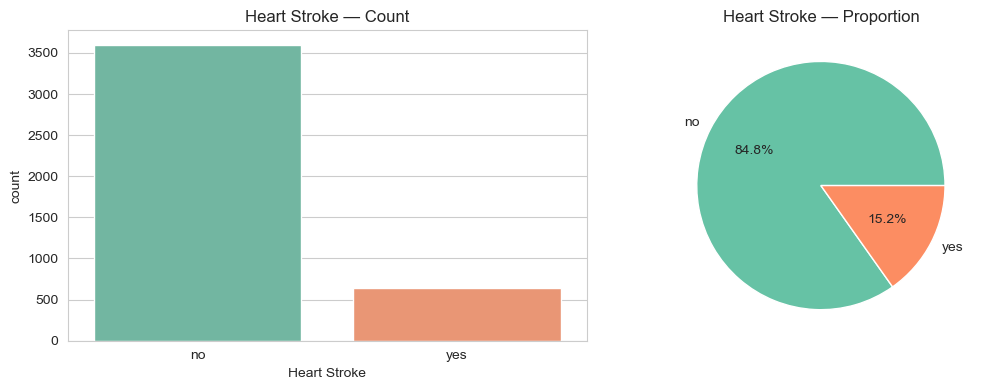

This is an imbalanced classification problem — the 'yes' class is a minority,
which is why regularization and class-weighting matter for these models.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="Heart_stroke", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Heart Stroke — Count")
axes[0].set_xlabel("Heart Stroke")

counts = df["Heart_stroke"].value_counts()
axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%", colors=sns.color_palette("Set2"))
axes[1].set_title("Heart Stroke — Proportion")

plt.tight_layout()
plt.show()

print("This is an imbalanced classification problem — the 'yes' class is a minority,")
print("which is why regularization and class-weighting matter for these models.")

### 3.2 Categorical feature distributions

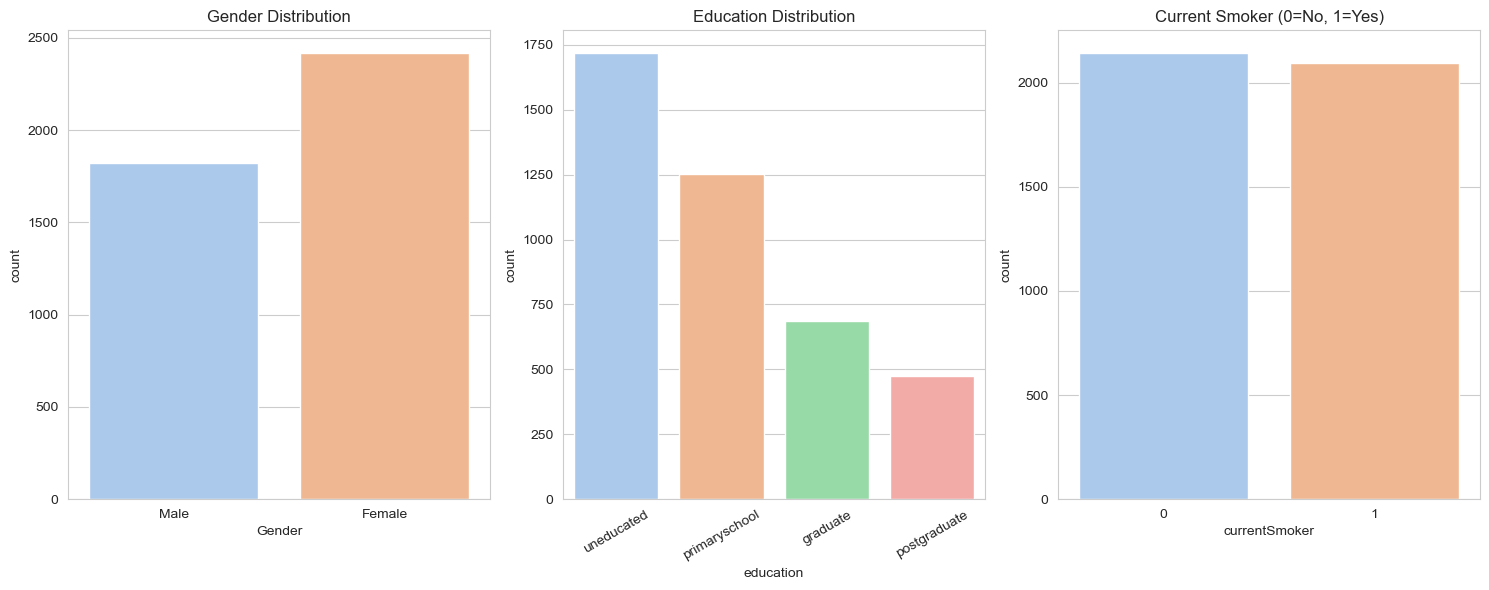

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

sns.countplot(x="Gender", data=df, ax=axes[0], palette="pastel")
axes[0].set_title("Gender Distribution")

order = ["uneducated", "primaryschool", "graduate", "postgraduate"]
sns.countplot(x="education", data=df, ax=axes[1], order=order, palette="pastel")
axes[1].set_title("Education Distribution")
axes[1].tick_params(axis="x", rotation=30)

sns.countplot(x="currentSmoker", data=df, ax=axes[2], palette="pastel")
axes[2].set_title("Current Smoker (0=No, 1=Yes)")

plt.tight_layout()
plt.show()

### 3.3 Numeric feature distributions

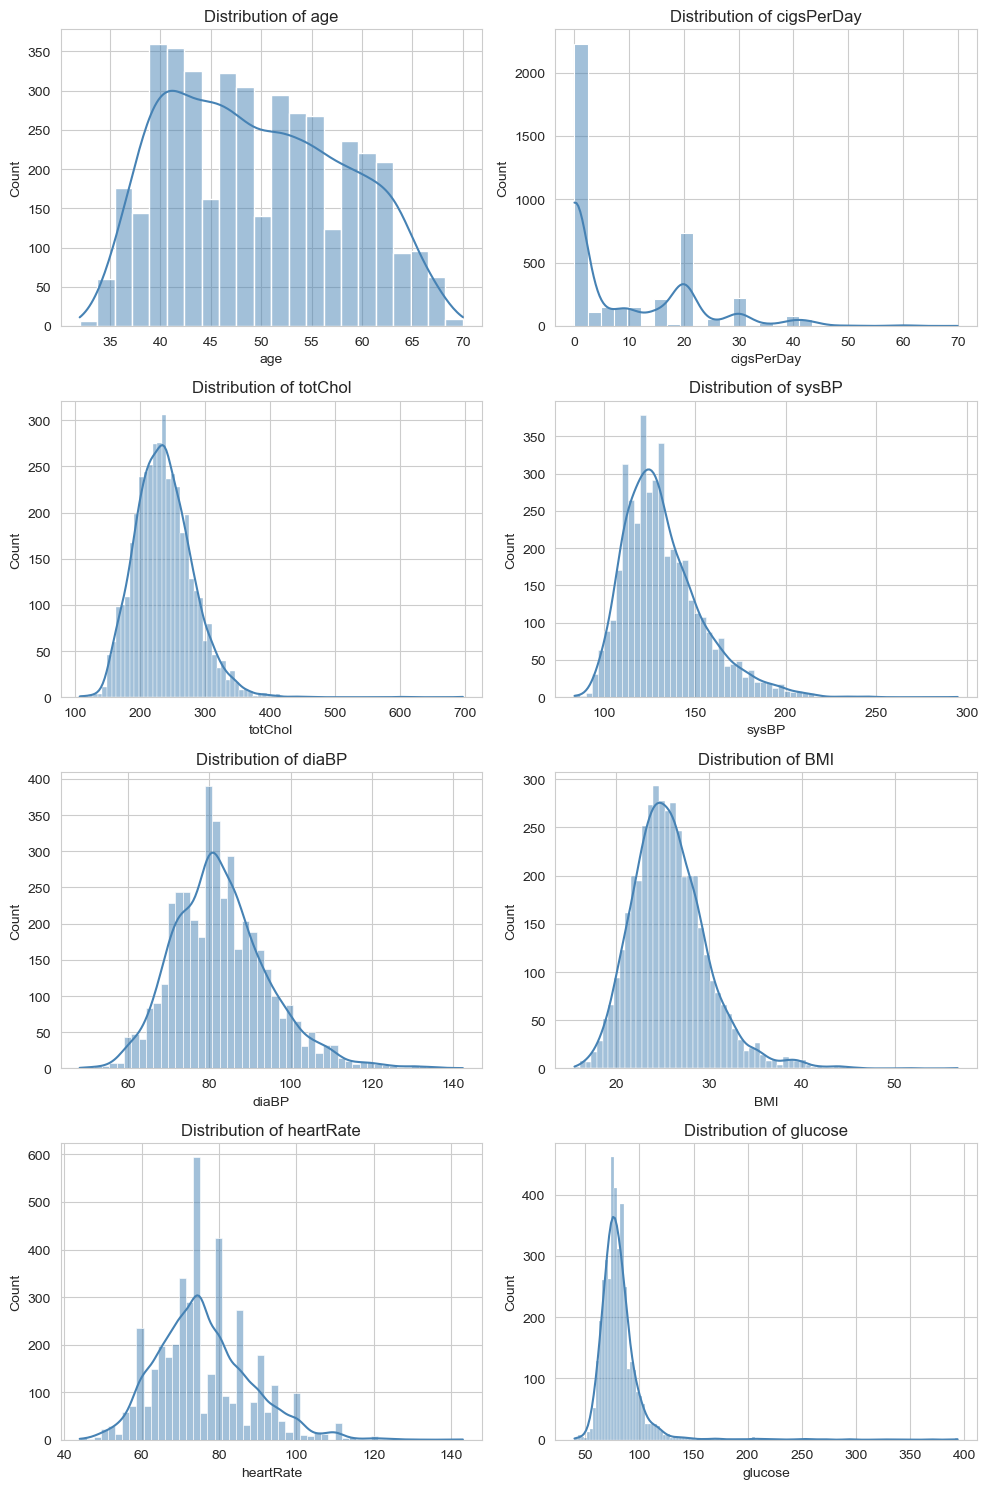

In [47]:
numeric_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

fig, axes = plt.subplots(4, 2, figsize=(10,15))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### 3.4 Outlier detection (boxplots)

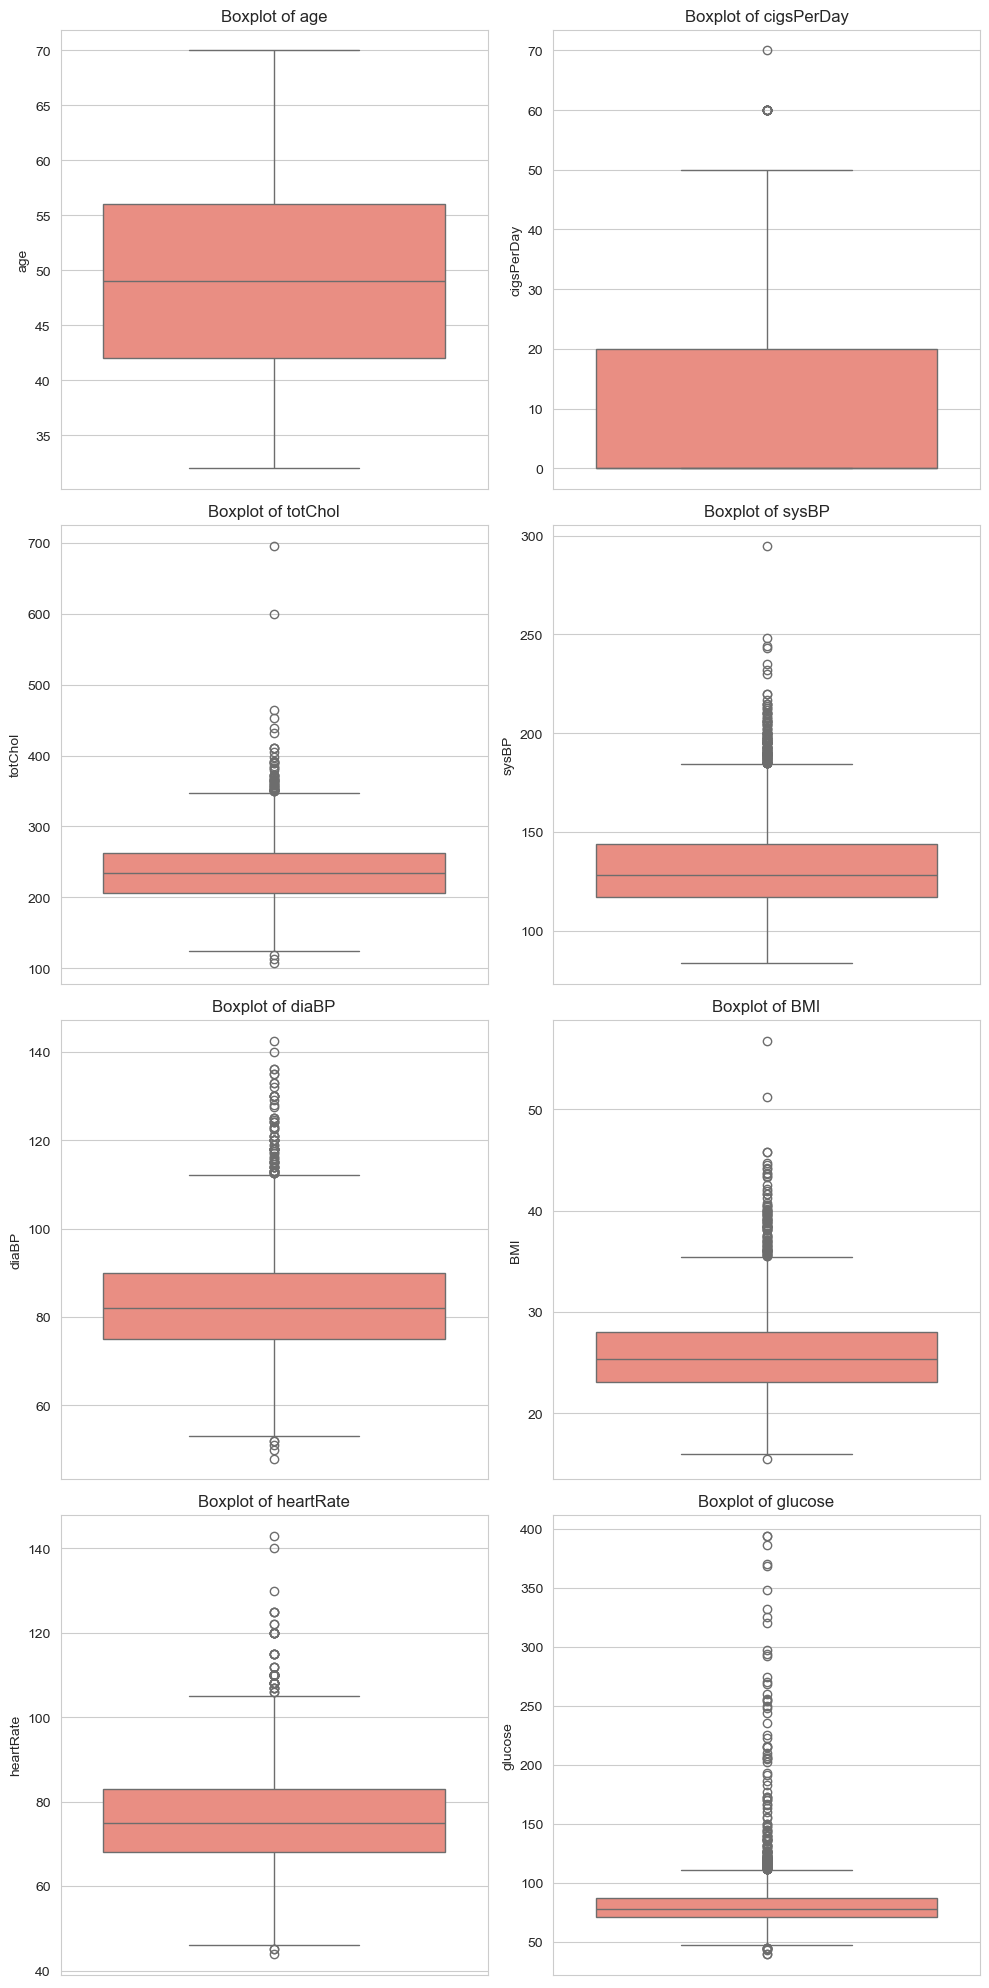

In [46]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="salmon")
    axes[i].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

### 3.5 Numeric features vs target

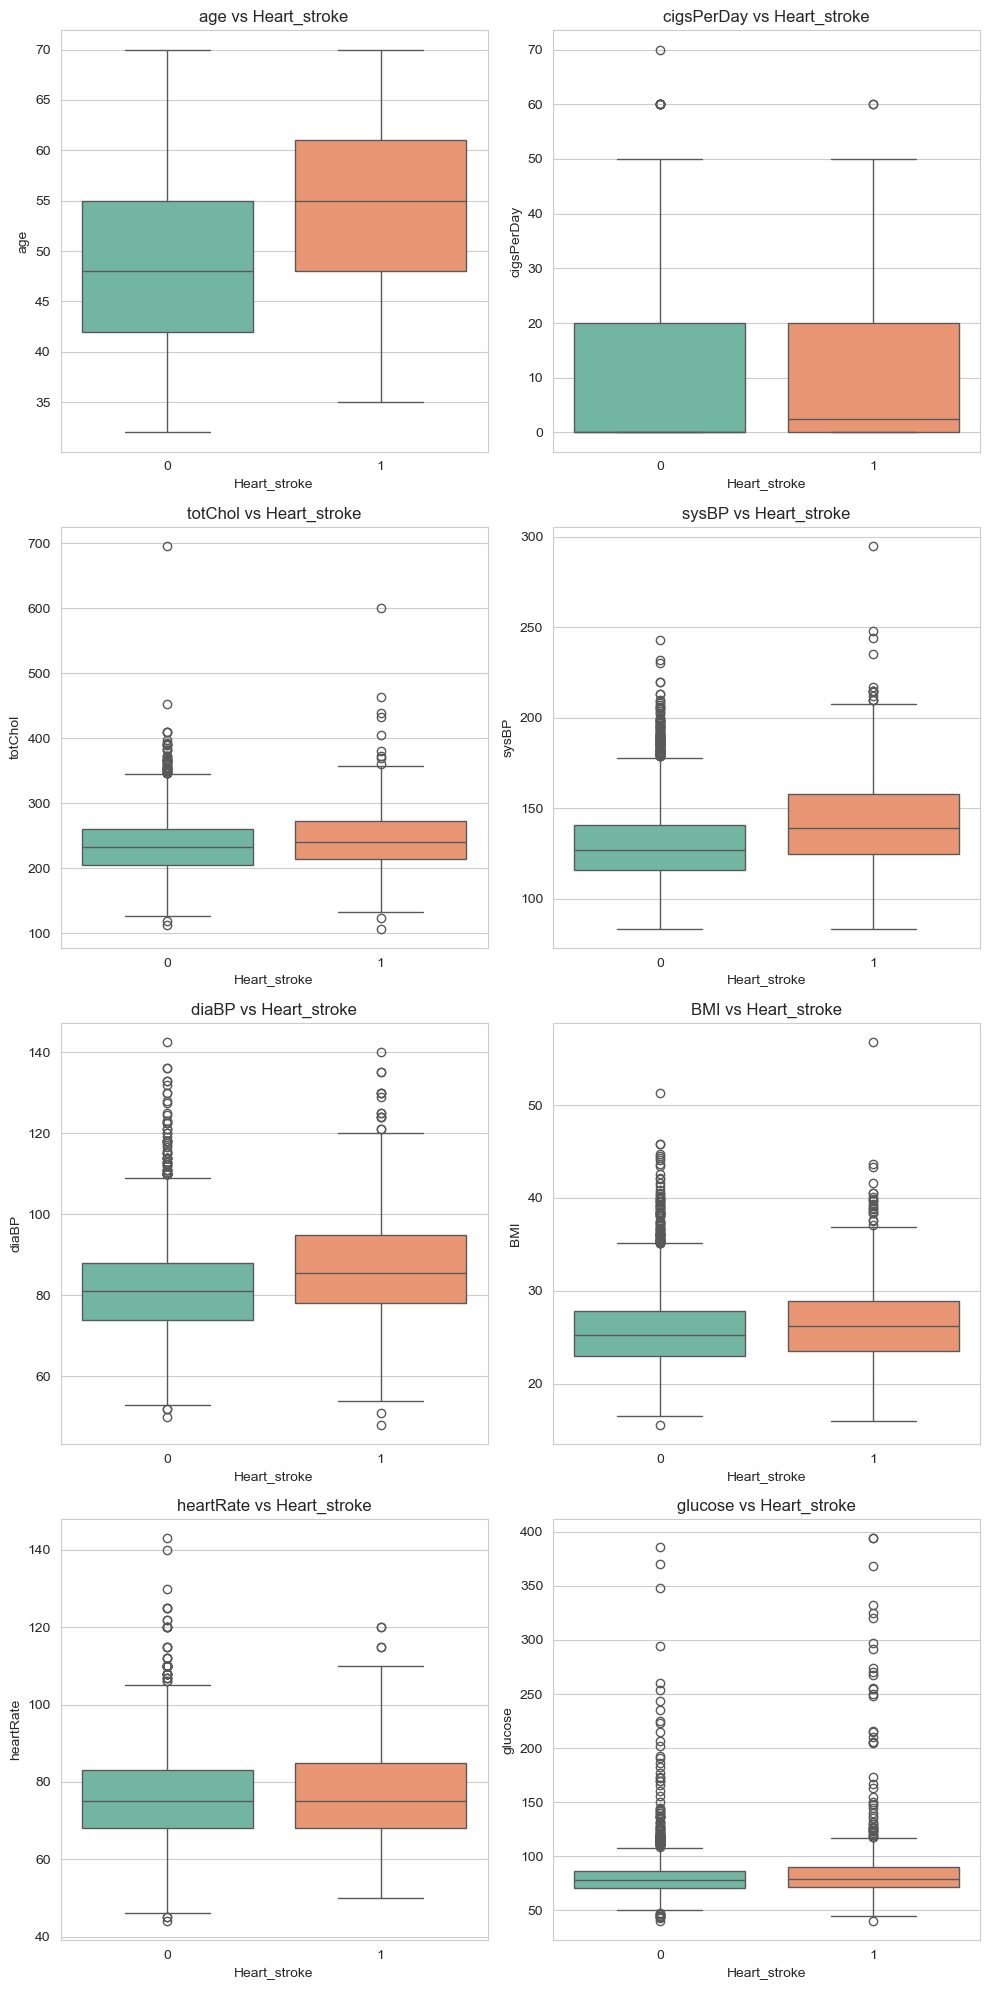

In [45]:
fig, axes = plt.subplots(4,2, figsize=(10,20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="Heart_stroke", y=col, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs Heart_stroke")
plt.tight_layout()
plt.show()

### 3.6 Categorical risk factors vs target

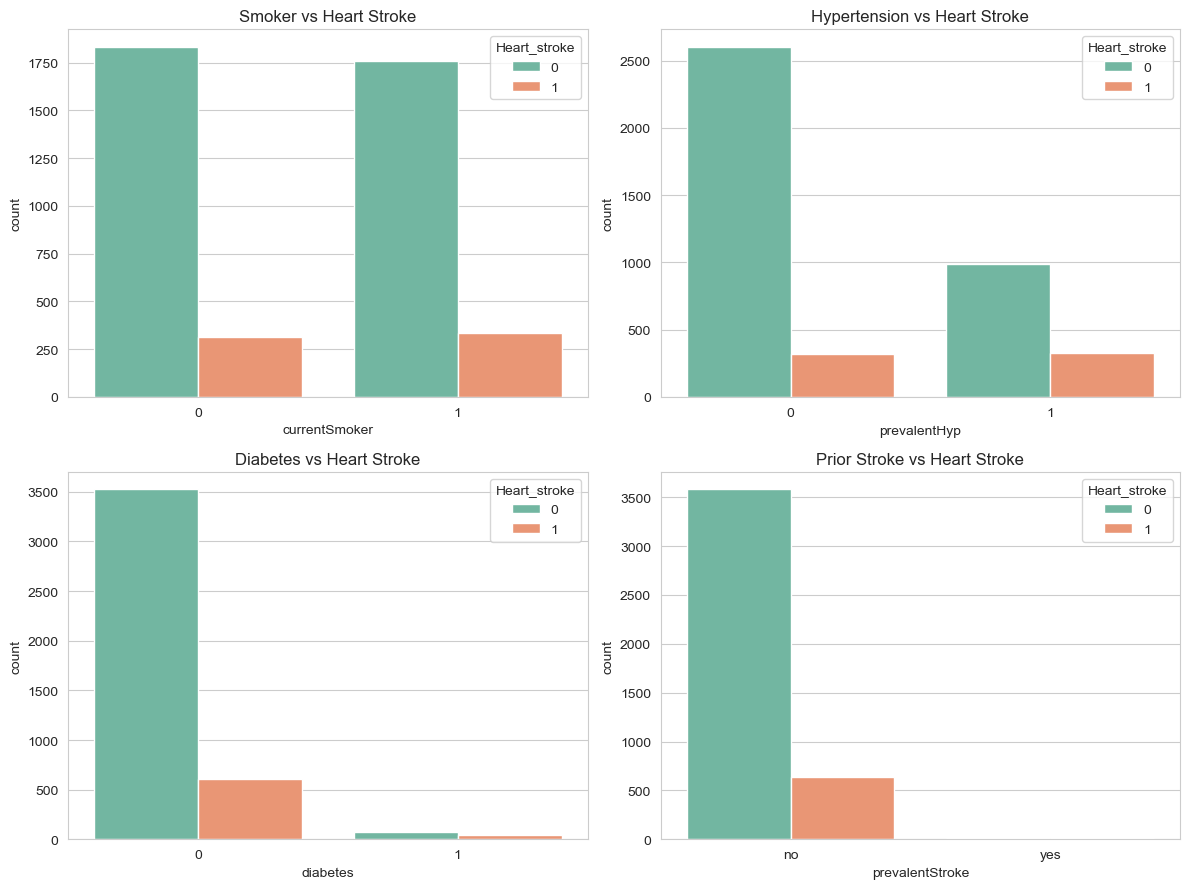

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(x="currentSmoker", hue="Heart_stroke", data=df, ax=axes[0][0], palette="Set2")
axes[0][0].set_title("Smoker vs Heart Stroke")

sns.countplot(x="prevalentHyp", hue="Heart_stroke", data=df, ax=axes[0][1], palette="Set2")
axes[0][1].set_title("Hypertension vs Heart Stroke")

sns.countplot(x="diabetes", hue="Heart_stroke", data=df, ax=axes[1][0], palette="Set2")
axes[1][0].set_title("Diabetes vs Heart Stroke")

sns.countplot(x="prevalentStroke", hue="Heart_stroke", data=df, ax=axes[1][1], palette="Set2")
axes[1][1].set_title("Prior Stroke vs Heart Stroke")

plt.tight_layout()
plt.show()

### 3.7 Correlation heatmap

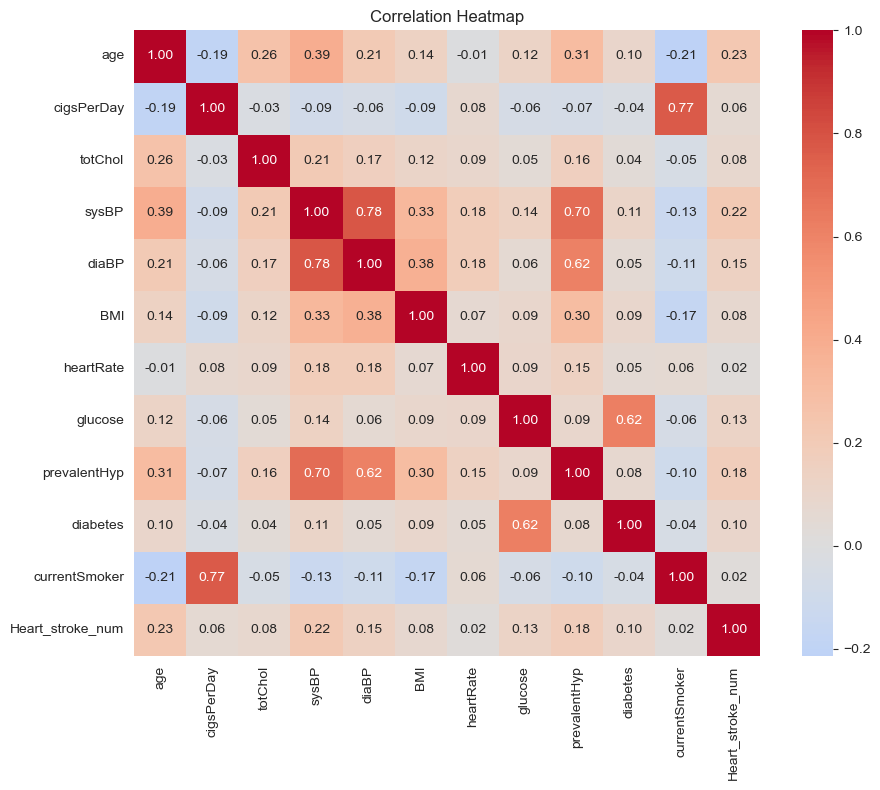

In [14]:
corr_df = df.copy()
corr_df["Heart_stroke_num"] = LabelEncoder().fit_transform(corr_df["Heart_stroke"])
corr = corr_df[numeric_cols + ["prevalentHyp", "diabetes", "currentSmoker", "Heart_stroke_num"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Encode the target

In [15]:
le_target = LabelEncoder()
df["Heart_stroke"] = le_target.fit_transform(df["Heart_stroke"])   # no -> 0, yes -> 1
print(dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

{'no': np.int64(0), 'yes': np.int64(1)}


### 4.2 Feature / target split

In [16]:
X = df.drop(columns="Heart_stroke")
y = df["Heart_stroke"]
X.shape, y.shape

((4238, 15), (4238,))

### 4.3 Column groups

In [17]:
num_features = ["age", "cigsPerDay", "BPMeds", "totChol", "sysBP",
                "diaBP", "BMI", "heartRate", "glucose"]
passthrough_features = ["currentSmoker", "prevalentHyp", "diabetes"]
gender_feature = ["Gender"]
education_feature = ["education"]
stroke_feature = ["prevalentStroke"]

num_features, passthrough_features

(['age',
  'cigsPerDay',
  'BPMeds',
  'totChol',
  'sysBP',
  'diaBP',
  'BMI',
  'heartRate',
  'glucose'],
 ['currentSmoker', 'prevalentHyp', 'diabetes'])

### 4.4 Preprocessing pipeline

- **Numeric columns** → median imputation (robust to outliers) + standard scaling
  (scaling is *required* for the regularized linear/SVM models below, since
  regularization penalizes coefficient magnitude and is scale-sensitive).
- **`education`** → most-frequent imputation + ordinal encoding (has a natural order).
- **`Gender` / `prevalentStroke`** → one-hot / ordinal encoding (no missing values).
- **Binary flags** (`currentSmoker`, `prevalentHyp`, `diabetes`) → passed through.

In [18]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

education_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[["uneducated", "primaryschool", "graduate", "postgraduate"]]))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("edu", education_pipeline, education_feature),
    ("gender", OneHotEncoder(drop="first", sparse_output=False), gender_feature),
    ("stroke", OrdinalEncoder(categories=[["no", "yes"]]), stroke_feature),
    ("pass", "passthrough", passthrough_features),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('edu', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

### 4.5 Train / test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape, y_train.value_counts(normalize=True).round(3).to_dict()

((3390, 15), (848, 15), {0: 0.848, 1: 0.152})

## 5. Classification Models — all fit with Regularization

Every model below is deliberately configured with a regularization mechanism to
control overfitting on this fairly small, imbalanced dataset:

| Model | Regularization mechanism |
|---|---|
| Logistic Regression (L2) | `penalty="l2"`, tuned `C` |
| Logistic Regression (L1) | `penalty="l1"`, `solver="liblinear"`, tuned `C` |
| Logistic Regression (ElasticNet) | `penalty="elasticnet"`, `l1_ratio`, `solver="saga"` |
| Ridge Classifier | L2 penalty via `alpha` |
| SGD Classifier | L2/L1/ElasticNet penalty on a linear model |
| SVM (Linear) | L2 penalty via cost `C` |
| SVM (RBF) | L2 penalty via cost `C` + kernel |
| KNN | `n_neighbors` (implicit smoothing / model complexity control) |
| Decision Tree | cost-complexity pruning `ccp_alpha` + `max_depth`, `min_samples_leaf` |
| Random Forest | `max_depth`, `min_samples_leaf`, `max_features` (bagging regularization) |
| Gradient Boosting | low `learning_rate` + shallow `max_depth` + subsampling |
| Gaussian Naive Bayes | baseline (no tunable regularization) |

All models use `class_weight="balanced"` where supported, to compensate for the class imbalance seen in the EDA.

In [20]:
models = {
    "Logistic Regression (L2)": LogisticRegression(
        penalty="l2", C=0.5, class_weight="balanced",
        max_iter=1000, random_state=RANDOM_STATE
    ),
    "Logistic Regression (L1)": LogisticRegression(
        penalty="l1", C=0.5, solver="liblinear", class_weight="balanced",
        max_iter=1000, random_state=RANDOM_STATE
    ),
    "Logistic Regression (ElasticNet)": LogisticRegression(
        penalty="elasticnet", C=0.5, l1_ratio=0.5, solver="saga",
        class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE
    ),
    "Ridge Classifier": RidgeClassifier(
        alpha=1.0, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "SGD Classifier (ElasticNet)": SGDClassifier(
        loss="log_loss", penalty="elasticnet", alpha=1e-3, l1_ratio=0.3,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "SVM (Linear)": SVC(
        kernel="linear", C=0.5, class_weight="balanced",
        probability=True, random_state=RANDOM_STATE
    ),
    "SVM (RBF)": SVC(
        kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
        probability=True, random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree (Pruned)": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=20, ccp_alpha=0.001,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest (Regularized)": RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=10,
        max_features="sqrt", class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting (Regularized)": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        subsample=0.8, random_state=RANDOM_STATE
    ),
    "Gaussian Naive Bayes": GaussianNB(),
}
len(models)

12

### 5.1 Train each model inside the preprocessing pipeline and evaluate

In [21]:
results = []
fitted_pipelines = {}
roc_data = {}

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_data[name] = (fpr, tpr)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "CV Accuracy (mean)": cv_scores.mean(),
        "CV Accuracy (std)": cv_scores.std(),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV Accuracy (mean),CV Accuracy (std)
0,SVM (Linear),0.640,0.235,0.605,0.338,0.700,0.659,0.014
1,Ridge Classifier,0.663,0.246,0.589,0.347,0.700,0.674,0.017
2,Logistic Regression (L2),0.671,0.250,0.581,0.350,0.699,0.673,0.021
3,Logistic Regression (ElasticNet),0.669,0.248,0.581,0.348,0.699,0.673,0.021
4,Logistic Regression (L1),0.667,0.249,0.589,0.350,0.698,0.670,0.021
5,Random Forest (Regularized),0.677,0.238,0.512,0.325,0.685,0.695,0.021
6,Gaussian Naive Bayes,0.807,0.254,0.140,0.180,0.680,0.828,0.008
7,SGD Classifier (ElasticNet),0.666,0.243,0.566,0.340,0.680,0.657,0.028
8,SVM (RBF),0.677,0.240,0.519,0.328,0.671,0.698,0.015
9,Gradient Boosting (Regularized),0.837,0.320,0.062,0.104,0.668,0.851,0.002


### 5.2 Model comparison chart

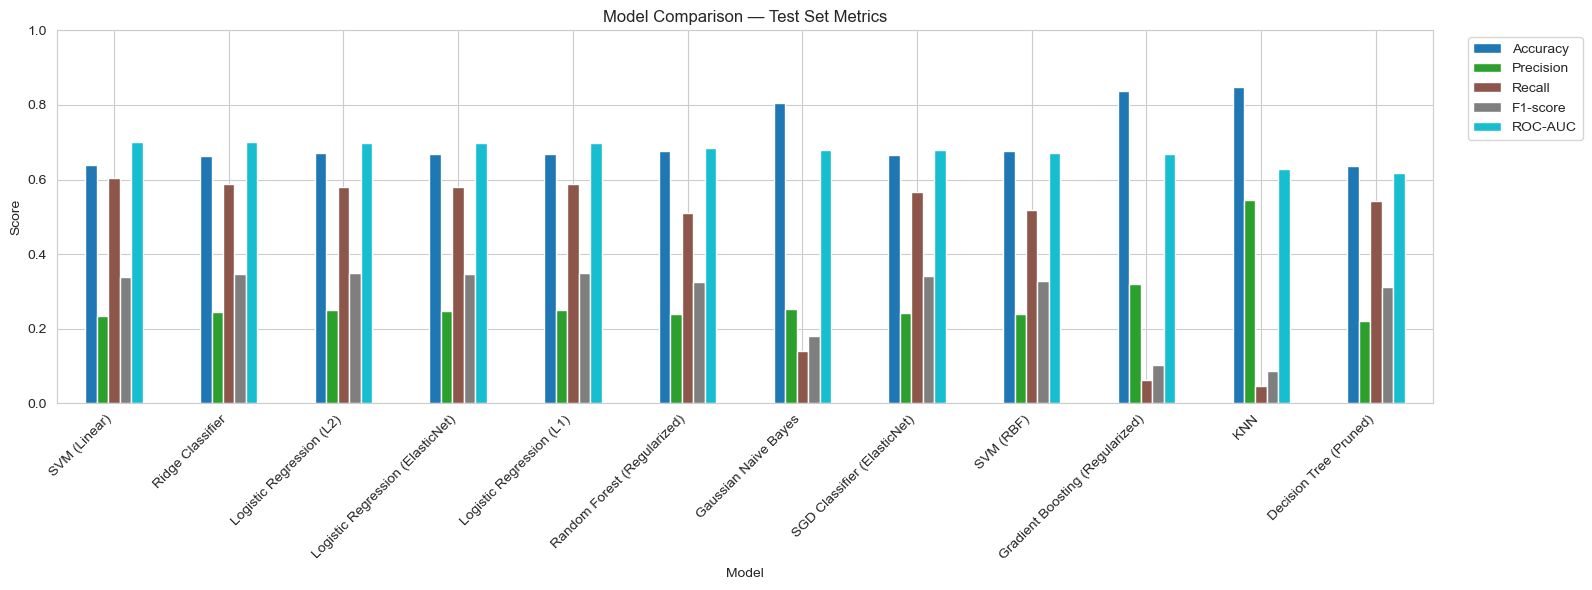

In [22]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(16, 6), colormap="tab10")
plt.title("Model Comparison — Test Set Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### 5.3 ROC curves — all models

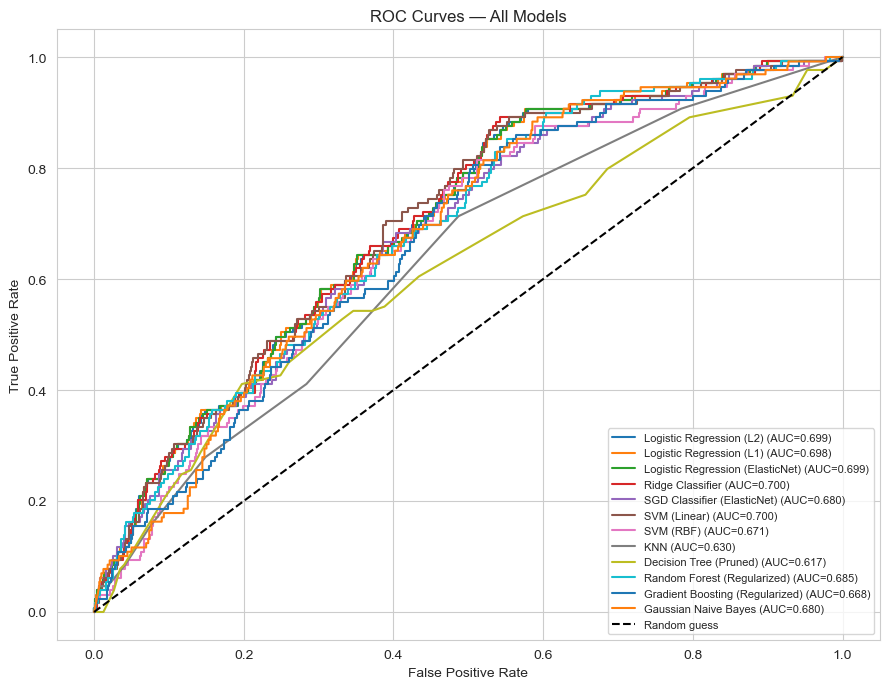

In [23]:
plt.figure(figsize=(9, 7))
for name, (fpr, tpr) in roc_data.items():
    auc_val = results_df.loc[results_df.Model == name, "ROC-AUC"].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### 5.4 Confusion matrices — all models

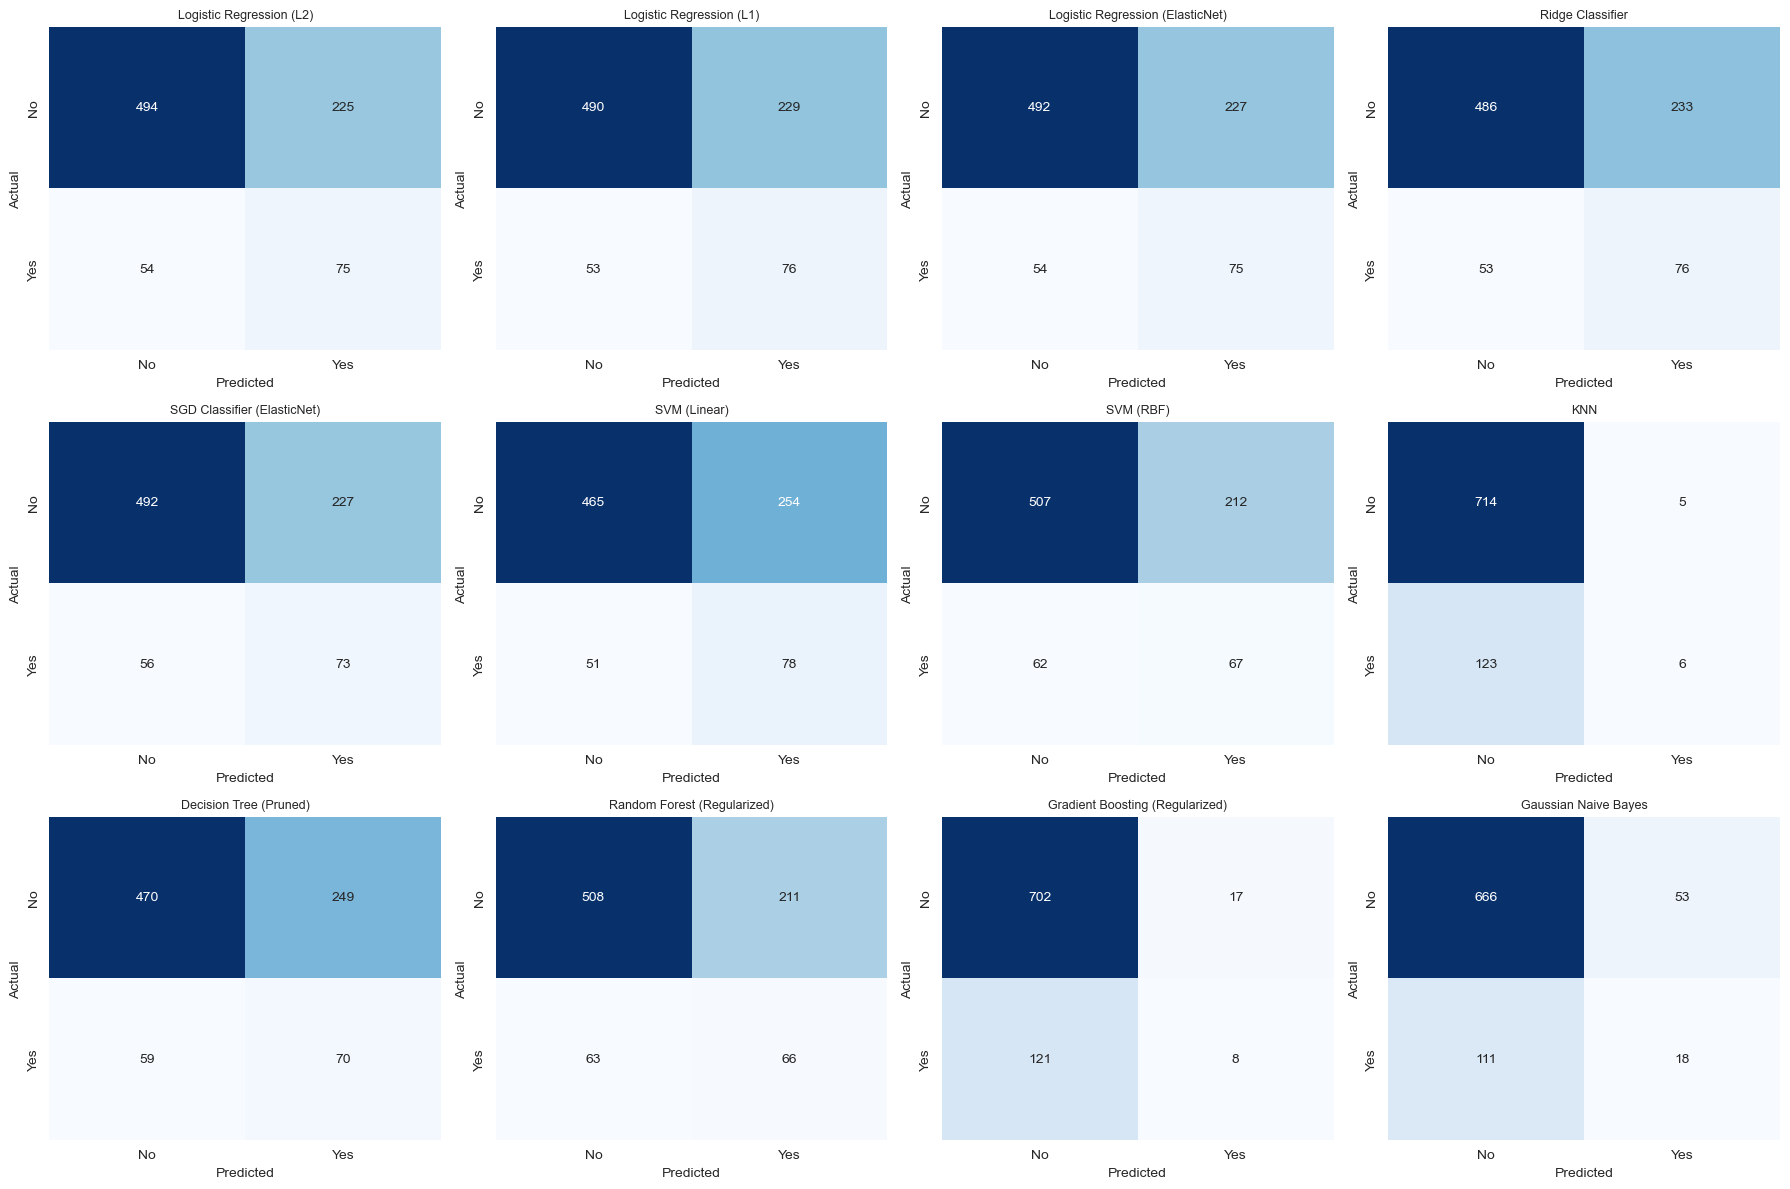

In [24]:
n_models = len(models)
n_cols = 4
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, (name, pipe) in enumerate(fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i],
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### 5.5 Best model — detailed report

In [25]:
best_model_name = results_df.iloc[0]["Model"]
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

print(f"Best model (by ROC-AUC): {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["No", "Yes"]))

Best model (by ROC-AUC): SVM (Linear)

              precision    recall  f1-score   support

          No       0.90      0.65      0.75       719
         Yes       0.23      0.60      0.34       129

    accuracy                           0.64       848
   macro avg       0.57      0.63      0.55       848
weighted avg       0.80      0.64      0.69       848



### 5.6 Regularization strength check — Logistic Regression L2

A quick sweep of `C` (inverse regularization strength) shows the classic
under-fit → sweet-spot → over-fit pattern as regularization is relaxed.

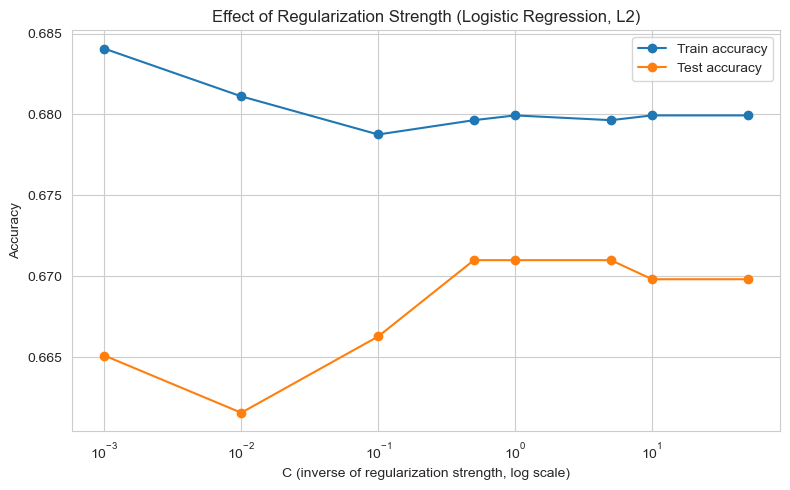

In [26]:
C_values = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50]
train_scores, test_scores = [], []

for c in C_values:
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(C=c, penalty="l2", class_weight="balanced",
                                      max_iter=1000, random_state=RANDOM_STATE))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(C_values, train_scores, marker="o", label="Train accuracy")
plt.plot(C_values, test_scores, marker="o", label="Test accuracy")
plt.xscale("log")
plt.xlabel("C (inverse of regularization strength, log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization Strength (Logistic Regression, L2)")
plt.legend()
plt.tight_layout()
plt.show()

### 5.7 Feature importance / coefficients

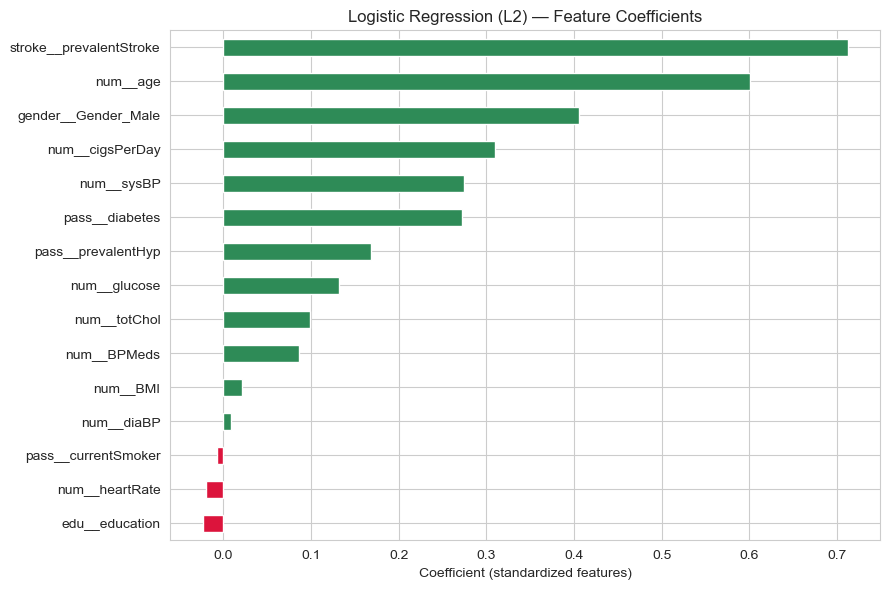

In [27]:
feature_names = fitted_pipelines[best_model_name].named_steps["preprocessing"].get_feature_names_out()

logreg_pipe = fitted_pipelines["Logistic Regression (L2)"]
coefs = pd.Series(
    logreg_pipe.named_steps["model"].coef_[0], index=feature_names
).sort_values()

plt.figure(figsize=(9, 6))
coefs.plot(kind="barh", color=coefs.apply(lambda v: "crimson" if v < 0 else "seagreen"))
plt.title("Logistic Regression (L2) — Feature Coefficients")
plt.xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()

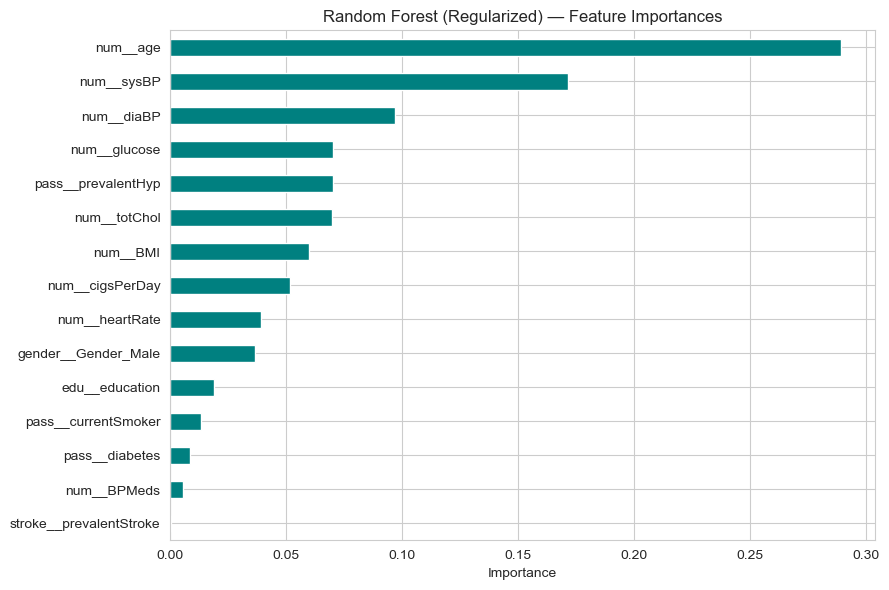

In [28]:
rf_pipe = fitted_pipelines["Random Forest (Regularized)"]
importances = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=feature_names
).sort_values()

plt.figure(figsize=(9, 6))
importances.plot(kind="barh", color="teal")
plt.title("Random Forest (Regularized) — Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 6. Boosting Accuracy — Hyperparameter Tuning + Ensemble

The models above used `class_weight="balanced"`, which trades some accuracy for better
recall on the minority class (important for not missing real heart-disease cases).
If **accuracy** is the priority metric, this section tunes hyperparameters with
`GridSearchCV` (`scoring="accuracy"`) **without** class balancing, and combines the
best models into a voting ensemble — usually the most reliable way to push accuracy
up beyond a single default model.

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier

param_grids = {
    "Logistic Regression (Tuned)": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"model__C": [0.01, 0.1, 1, 10, 100], "model__penalty": ["l2"]}
    ),
    "KNN (Tuned)": (
        KNeighborsClassifier(),
        {"model__n_neighbors": [5, 9, 15, 21, 31, 41], "model__weights": ["uniform", "distance"]}
    ),
    "Random Forest (Tuned)": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [200, 400], "model__max_depth": [4, 6, 10, None],
         "model__min_samples_leaf": [1, 5, 10]}
    ),
    "Gradient Boosting (Tuned)": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200], "model__learning_rate": [0.01, 0.05, 0.1],
         "model__max_depth": [2, 3, 4]}
    ),
    "SVM RBF (Tuned)": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.01, 0.1]}
    ),
}

tuned_results = []
best_estimators = {}

for name, (est, grid) in param_grids.items():
    pipe = Pipeline([("preprocessing", preprocessor), ("model", est)])
    gs = GridSearchCV(pipe, grid, scoring="accuracy", cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_

    y_pred = gs.predict(X_test)
    y_score = gs.predict_proba(X_test)[:, 1] if hasattr(gs, "predict_proba") else gs.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_data[name] = (fpr, tpr)
    fitted_pipelines[name] = gs.best_estimator_

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Best Params": gs.best_params_,
    })
    print(f"{name}: best CV accuracy = {gs.best_score_:.3f}, best params = {gs.best_params_}")

tuned_df = pd.DataFrame(tuned_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
tuned_df.drop(columns="Best Params").round(3)

Logistic Regression (Tuned): best CV accuracy = 0.855, best params = {'model__C': 100, 'model__penalty': 'l2'}
KNN (Tuned): best CV accuracy = 0.850, best params = {'model__n_neighbors': 21, 'model__weights': 'distance'}
Random Forest (Tuned): best CV accuracy = 0.850, best params = {'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
Gradient Boosting (Tuned): best CV accuracy = 0.849, best params = {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}
SVM RBF (Tuned): best CV accuracy = 0.849, best params = {'model__C': 10, 'model__gamma': 0.01}


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM RBF (Tuned),0.849,0.600,0.023,0.045,0.535
1,Logistic Regression (Tuned),0.848,0.500,0.070,0.122,0.700
2,KNN (Tuned),0.848,0.500,0.031,0.058,0.637
3,Random Forest (Tuned),0.846,0.250,0.008,0.015,0.669
4,Gradient Boosting (Tuned),0.842,0.143,0.008,0.015,0.688


### 6.1 Voting ensemble of the strongest tuned models

In [30]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", best_estimators["Logistic Regression (Tuned)"].named_steps["model"]),
        ("rf", best_estimators["Random Forest (Tuned)"].named_steps["model"]),
        ("gb", best_estimators["Gradient Boosting (Tuned)"].named_steps["model"]),
    ],
    voting="soft"
)

voting_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", voting_model)
])
voting_pipe.fit(X_train, y_train)
fitted_pipelines["Voting Ensemble (Tuned)"] = voting_pipe

y_pred = voting_pipe.predict(X_test)
y_score = voting_pipe.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_data["Voting Ensemble (Tuned)"] = (fpr, tpr)

ensemble_row = {
    "Model": "Voting Ensemble (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_score),
}
tuned_df = pd.concat([tuned_df, pd.DataFrame([{**ensemble_row, "Best Params": "-"}])], ignore_index=True)
tuned_df = tuned_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
tuned_df.drop(columns="Best Params").round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM RBF (Tuned),0.849,0.600,0.023,0.045,0.535
1,Logistic Regression (Tuned),0.848,0.500,0.070,0.122,0.700
2,KNN (Tuned),0.848,0.500,0.031,0.058,0.637
3,Voting Ensemble (Tuned),0.847,0.400,0.016,0.030,0.690
4,Random Forest (Tuned),0.846,0.250,0.008,0.015,0.669
5,Gradient Boosting (Tuned),0.842,0.143,0.008,0.015,0.688


### 6.2 Accuracy-optimized models — comparison chart

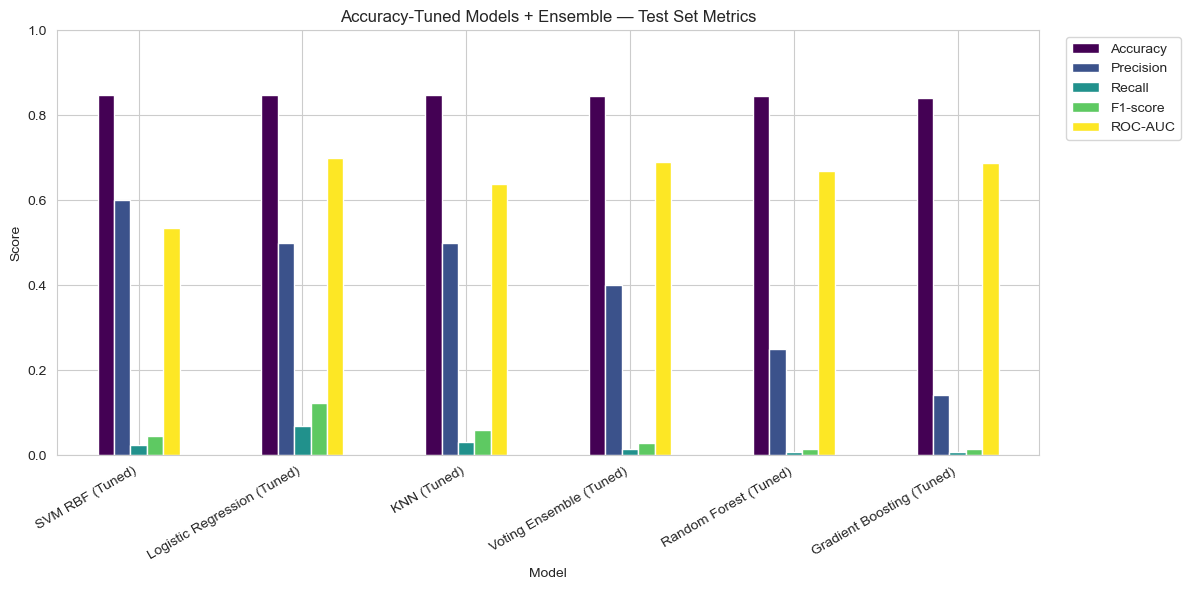

In [31]:
plot_df2 = tuned_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]]

plot_df2.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Accuracy-Tuned Models + Ensemble — Test Set Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6.3 Best accuracy model — detailed report

Highest-accuracy model: SVM RBF (Tuned)
Test accuracy: 84.906

              precision    recall  f1-score   support

          No       0.85      1.00      0.92       719
         Yes       0.60      0.02      0.04       129

    accuracy                           0.85       848
   macro avg       0.73      0.51      0.48       848
weighted avg       0.81      0.85      0.79       848



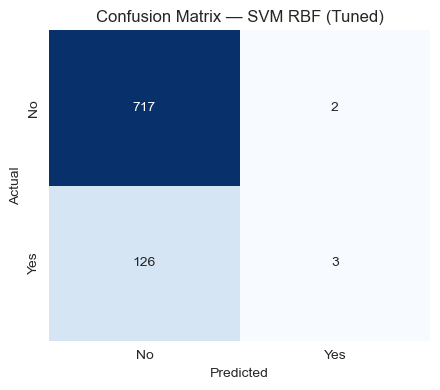

In [32]:
best_acc_name = tuned_df.iloc[0]["Model"]
best_acc_pipe = fitted_pipelines[best_acc_name]
y_pred_acc = best_acc_pipe.predict(X_test)

print(f"Highest-accuracy model: {best_acc_name}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_acc)*100:.3f}\n")
print(classification_report(y_test, y_pred_acc, target_names=["No", "Yes"]))

cm = confusion_matrix(y_test, y_pred_acc)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title(f"Confusion Matrix — {best_acc_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**Note the trade-off:** the highest-accuracy model above is not tuned with
class balancing, so it will tend to predict the majority ("No") class more often —
check its recall on the "Yes" class in the classification report. If missing a
real heart-disease case matters more than a false alarm, the balanced models in
§5 (or threshold tuning) are the better choice despite the lower raw accuracy.

## 7. Conclusion

- The dataset is **imbalanced** (far fewer positive `Heart_stroke` cases), which motivated using
  `class_weight="balanced"` across models and looking at **ROC-AUC / F1** rather than accuracy alone.
- Missing values were handled with **median** (numeric) and **most-frequent** (education) imputation.
- Categorical variables were encoded appropriately: **ordinal** for `education`/`prevalentStroke`
  (natural order) and **one-hot** for `Gender`.
- All numeric features were **standardized**, which is required for the regularization penalties
  (L1/L2/ElasticNet) in the linear models and SVMs to behave consistently across features.
- Every model was fit **with an explicit regularization mechanism** (L1/L2/ElasticNet penalties,
  pruning, shallow trees, subsampling, or neighbor smoothing) to reduce overfitting risk.
- The results table (`results_df`) and ROC/confusion-matrix plots above let you compare models
  directly; the top-ranked model by ROC-AUC is printed with a full classification report in §5.5.